## Noise Bliss
###### https://github.com/calanuzao/noise-bliss
Denoising Algorithms for Acoustic Scene Classification in Deep Learning Models with the SONYC-UST Dataset

In [1]:
# libraries
import utils as u
import models as m 

# apis
import IPython.display as ipd 
import matplotlib.pyplot as plt
import os
import pandas as pd
import random
import torch
import torchaudio

# validating audio data set
import soundata

In [2]:
# tensorflow and tensorflow-metal
import tensorflow as tf
print("TensorFlow Version: ", tf.__version__)
print("Is GPU available: ", tf.config.list_physical_devices("GPU"))

TensorFlow Version:  2.19.0
Is GPU available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#### Utilizing Soundata as Data Loader
https://soundata.readthedocs.io/en/latest/

In [3]:
# available datasets in soundata
for dataset in soundata.list_datasets():
    print(dataset)

dcase23_task2
dcase23_task4b
dcase23_task6a
dcase23_task6b
dcase_bioacoustic
dcase_birdVox20k
eigenscape
eigenscape_raw
esc50
freefield1010
fsd50k
fsdnoisy18k
marco
singapura
starss2022
tau2019sse
tau2019uas
tau2020sse_nigens
tau2020uas_mobile
tau2021sse_nigens
tau2022uas_mobile
tut2017se
urbansed
urbansound8k
warblrb10k


#### Defining data directory and and structure.

In [4]:
data_home = '/Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust'

annotations_path = os.path.join(data_home, 'annotations.csv')
debug_df = pd.read_csv(annotations_path)
print("Columns in annotations.csv:")
print(debug_df.columns.tolist())
print("\nFirst few rows:")
print(debug_df.head())

Columns in annotations.csv:
['split', 'sensor_id', 'audio_filename', 'annotator_id', 'borough', 'block', 'latitude', 'longitude', 'year', 'week', 'day', 'hour', '1-1_small-sounding-engine_presence', '1-2_medium-sounding-engine_presence', '1-3_large-sounding-engine_presence', '1-X_engine-of-uncertain-size_presence', '2-1_rock-drill_presence', '2-2_jackhammer_presence', '2-3_hoe-ram_presence', '2-4_pile-driver_presence', '2-X_other-unknown-impact-machinery_presence', '3-1_non-machinery-impact_presence', '4-1_chainsaw_presence', '4-2_small-medium-rotating-saw_presence', '4-3_large-rotating-saw_presence', '4-X_other-unknown-powered-saw_presence', '5-1_car-horn_presence', '5-2_car-alarm_presence', '5-3_siren_presence', '5-4_reverse-beeper_presence', '5-X_other-unknown-alert-signal_presence', '6-1_stationary-music_presence', '6-2_mobile-music_presence', '6-3_ice-cream-truck_presence', '6-X_music-from-uncertain-source_presence', '7-1_person-or-small-group-talking_presence', '7-2_person-or-sma

In [5]:
try:
    audio_files, labels = u.load_data(data_home)
    print(f"Successfully loaded {len(audio_files)} audio files")
    if len(audio_files) > 0:
        print("\nSample audio file:", audio_files[0])
        print("\nSample label (multi-hot encoded):", labels[0])
        print("\nLabel meanings:")
        for category, idx in u.label_taxonomy.items():
            if labels[0][idx] == 1:
                print(f"- {category}")
except Exception as e:
    print(f"Error loading data: {str(e)}")
    import traceback
    print(traceback.format_exc())

Successfully loaded 18510 audio files

Sample audio file: /Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/00_026884.wav

Sample label (multi-hot encoded): [1, 1, 1, 0, 0, 0, 0, 0]

Label meanings:
- engine
- machinery-impact
- non-machinery-impact


#### Understanding and Plotting Data.

Train sensors       : {1, 2, 8, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 45}
Validate sensors    : {0, 3, 4, 5, 6, 7, 9, 10, 46}
Test sensors        : {0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 16, 17, 18, 20, 22, 23, 24, 25, 27, 29, 30, 31, 32, 33, 34, 35, 37, 38, 39, 40, 41, 45, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 61}


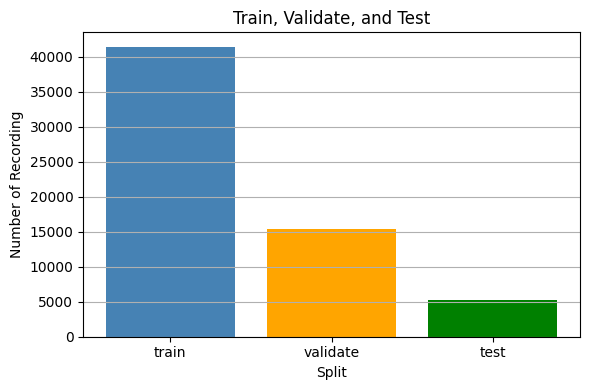

In [6]:
# plotting data
train_df = debug_df[debug_df['split'] == 'train']
valid_df = debug_df[debug_df['split'] == 'validate']
test_df = debug_df[debug_df['split'] == 'test']

# printing sensor sets
print("Train sensors       :", set(train_df['sensor_id']))
print("Validate sensors    :", set(valid_df['sensor_id']))
print("Test sensors        :", set(test_df['sensor_id']))

# counting reading per split
split_counts = debug_df['split'].value_counts().reindex(
    ['train', 'validate', 'test'], fill_value=0
)

# plotting recordings
plt.figure(figsize=(6, 4))
colors = ['steelblue', 'orange', 'green']
plt.bar(split_counts.index, split_counts.values, color=colors[:len(split_counts)])

plt.title('Train, Validate, and Test')
plt.xlabel('Split')
plt.ylabel('Number of Recording')
plt.grid(axis='y')
plt.tight_layout()
plt.legend
plt.show()

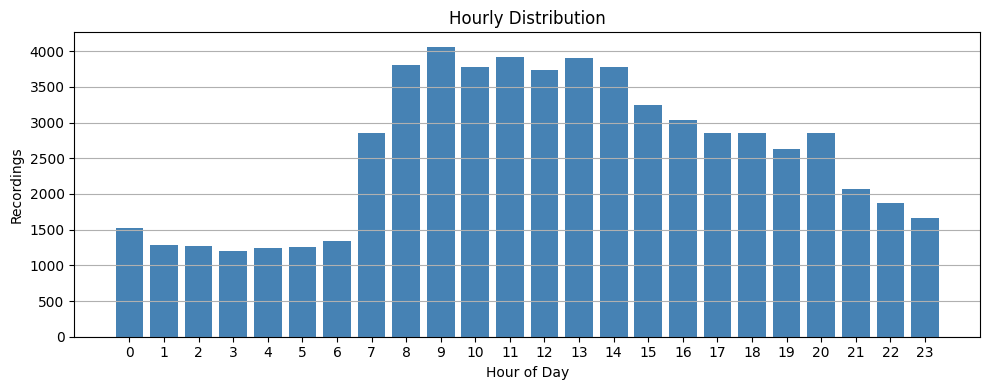

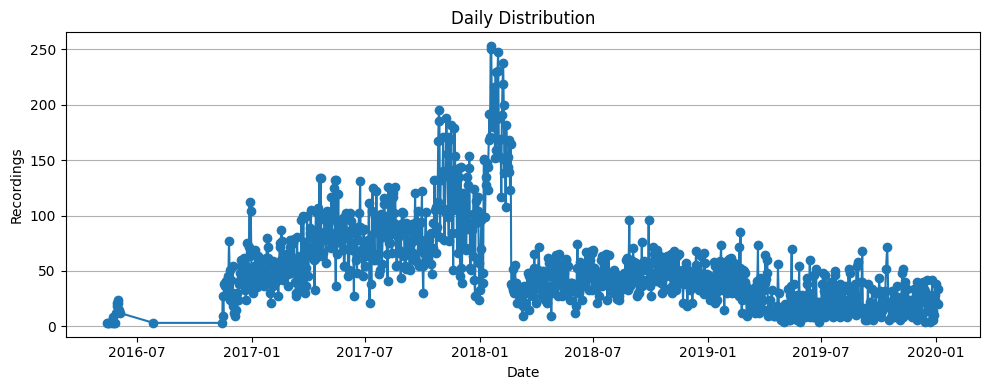

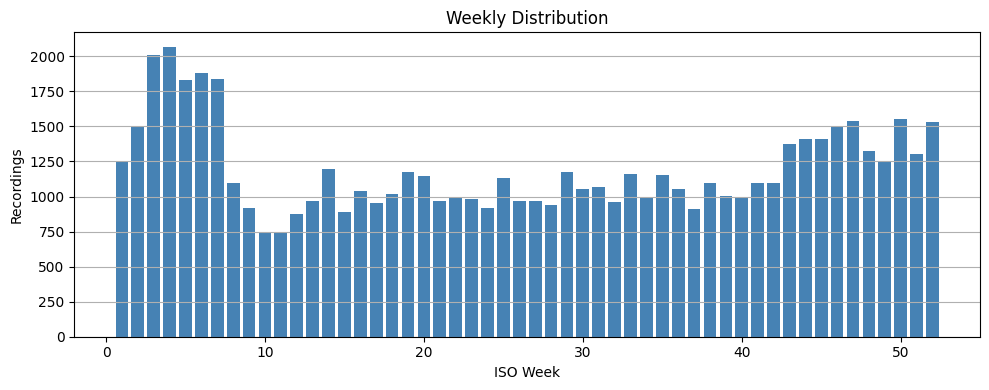

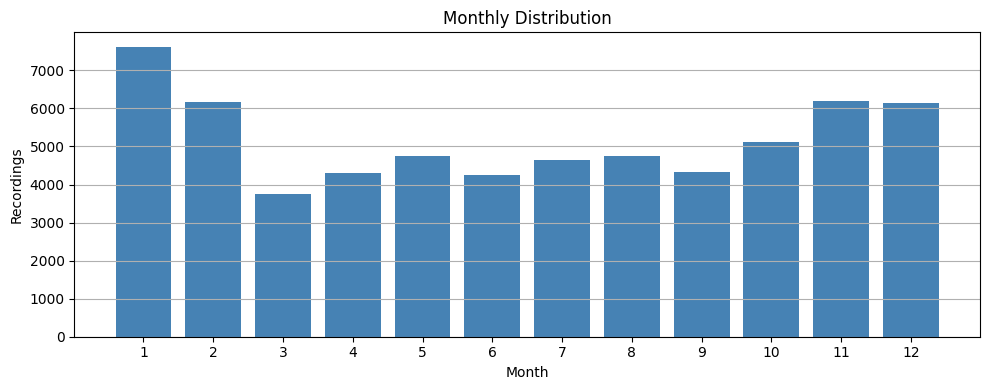

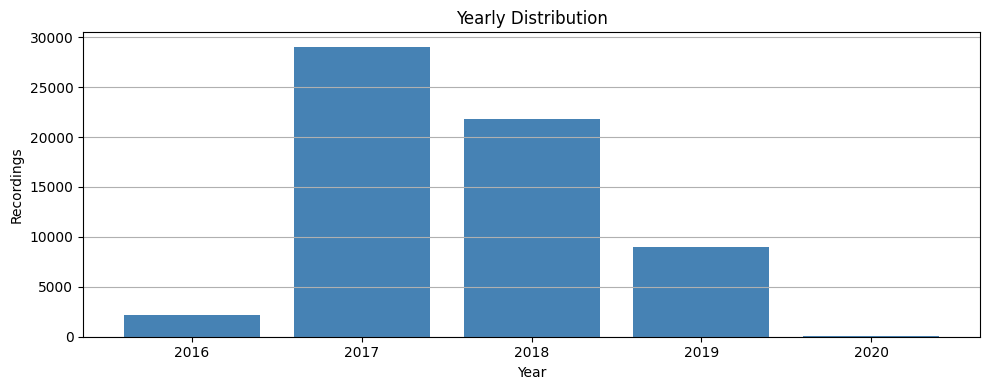

In [7]:
# plotting temporal data 
debug_df = u.construct_datetime(debug_df)
u.compute_and_plot_distributions(debug_df)

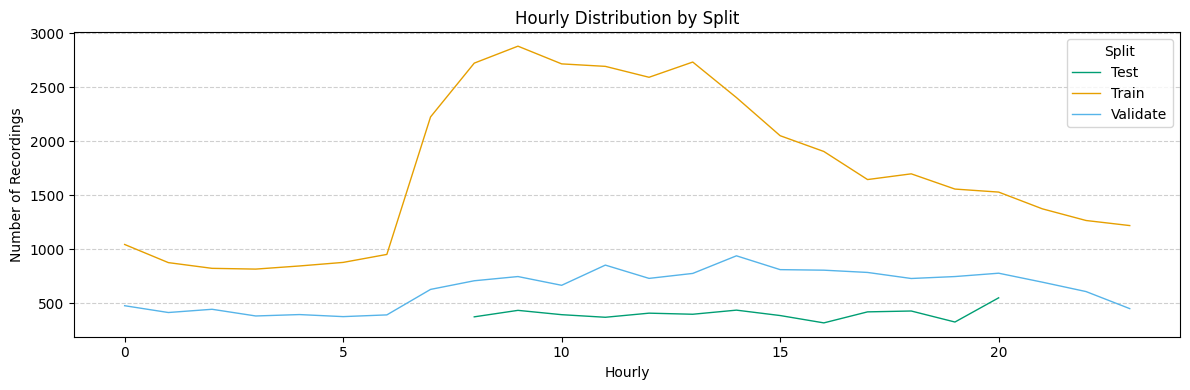

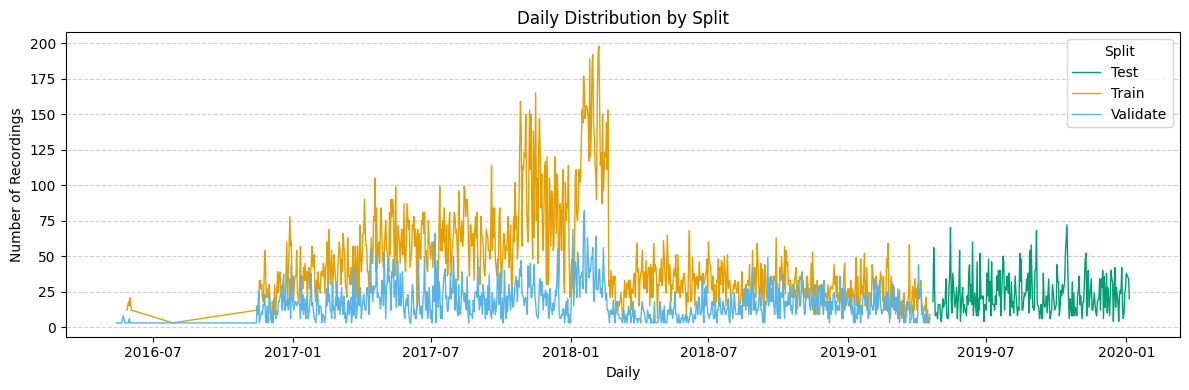

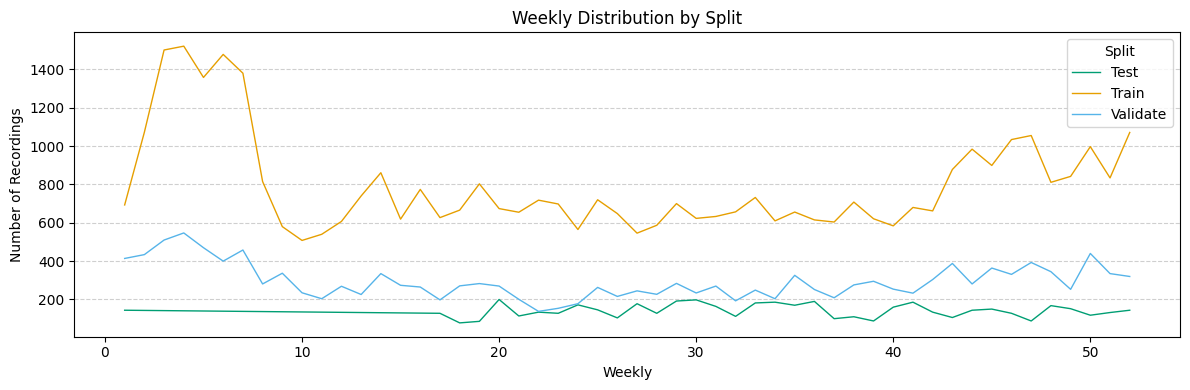

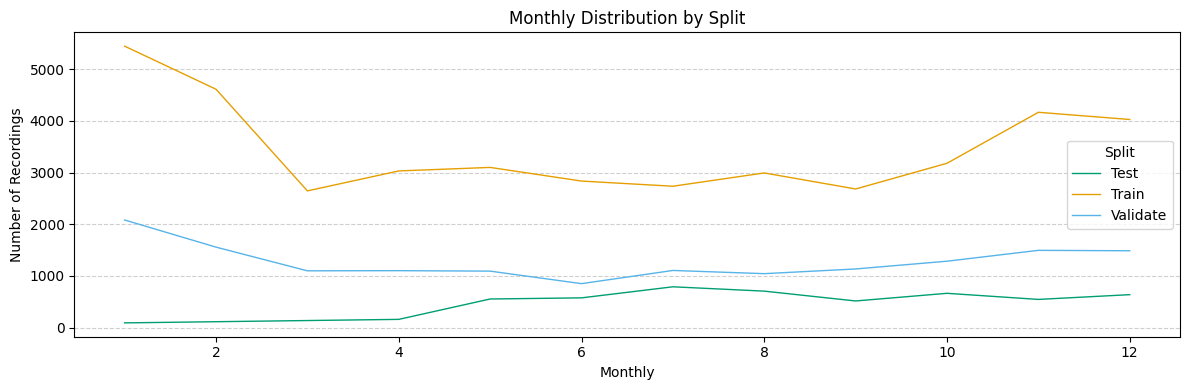

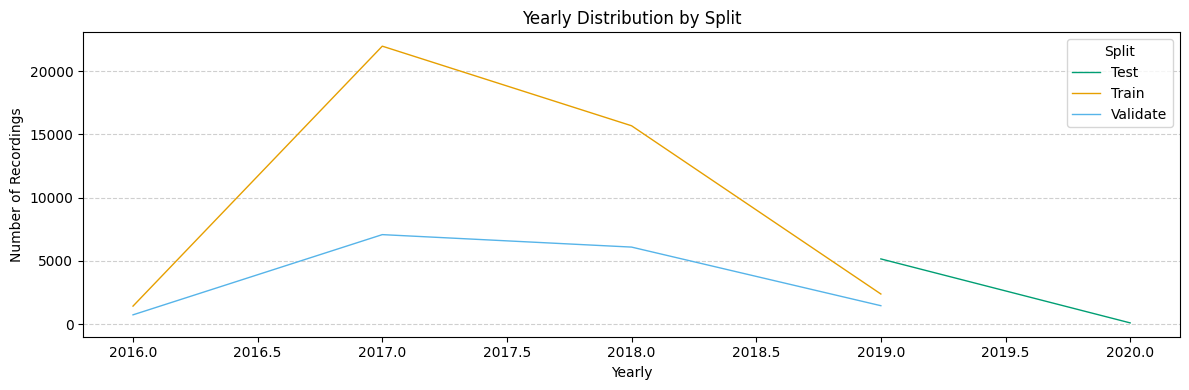

In [8]:
# plotting temporal data by split
u.plot_distributions_by_split(debug_df)

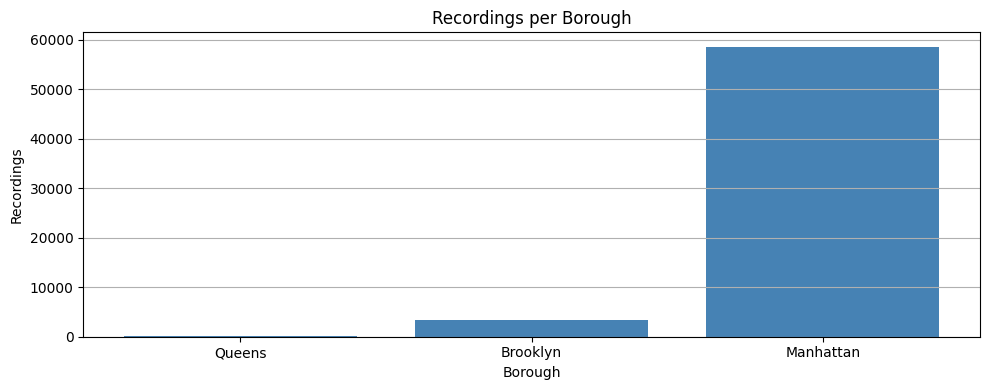

In [9]:
# borough mapping
borough_map = {
    1: "Manhattan",
    2: "Bronx",
    3: "Brooklyn",
    4: "Queens",
    5: "Staten Island"
}

# Map borough ID to name
debug_df['borough_name'] = debug_df['borough'].map(borough_map)

# Count number of recordings per borough (with data)
borough_counts = debug_df['borough_name'].value_counts().sort_index()

# Order from greatest to least
ordered_boroughs = [name for id_, name in borough_map.items() if name in borough_counts.index]
borough_counts = borough_counts[ordered_boroughs]
borough_counts = borough_counts.sort_values(ascending=True)

# ---------- Plot ----------
u.plot_distribution(
    borough_counts,
    xlabel="Borough",
    ylabel="Recordings",
    title="Recordings per Borough"
)

/var/folders/7s/4_xdxsgd3g717br165rj0xy00000gn/T/ipykernel_34950/402717847.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ordered_sensors.groupby('borough_name')


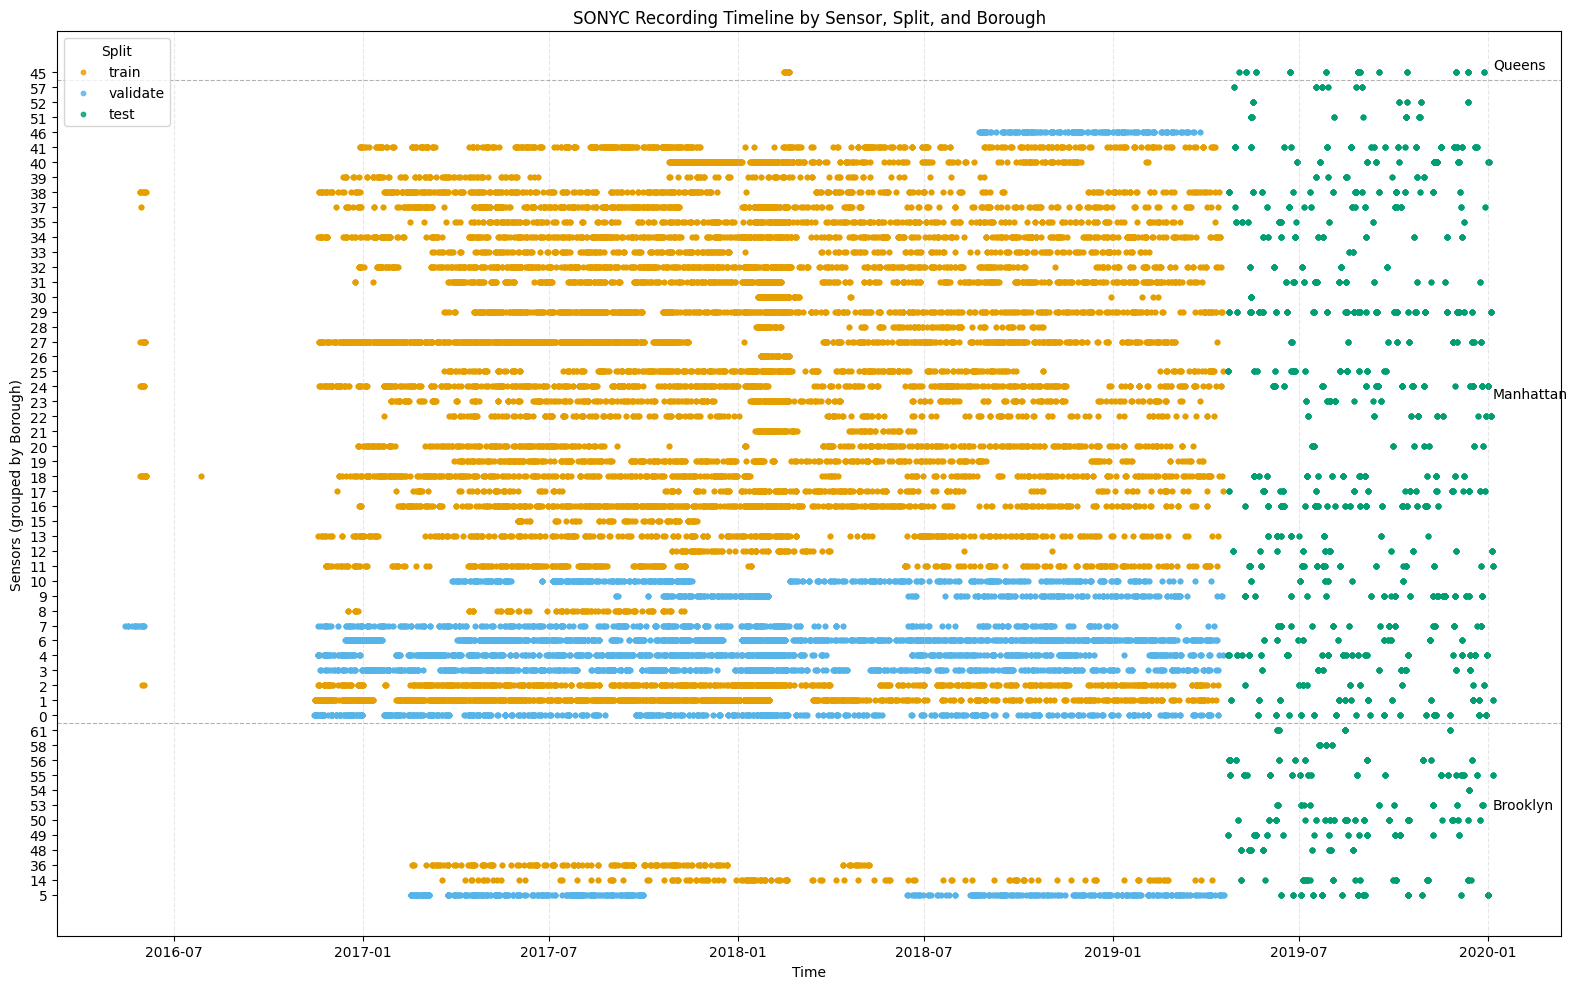

In [10]:
borough_map = {
    1: "Manhattan",
    2: "Bronx",
    3: "Brooklyn",
    4: "Queens",
    5: "Staten Island"
}

debug_df['borough_name'] = debug_df['borough'].map(borough_map)

ordered_sensors = (
    debug_df[['sensor_id', 'borough_name']]
    .drop_duplicates()
    .sort_values(['borough_name', 'sensor_id'])
)

sensor_order = {sid: i for i, sid in enumerate(ordered_sensors['sensor_id'])}
debug_df['sensor_y'] = debug_df['sensor_id'].map(sensor_order)

split_colors = {
    'train': '#E69F00',     # orange
    'validate': '#56B4E9',  # sky blue
    'test': '#009E73'       # teal
}

plt.style.use('default')
fig, ax = plt.subplots(figsize=(16, 10))

for split, color in split_colors.items():
    subset = debug_df[debug_df['split'] == split]
    ax.scatter(
        subset['datetime'],
        subset['sensor_y'],
        s=10,
        color=color,
        alpha=0.8,
        label=split
    )

borough_boundaries = []
current_borough = None

for i, (_, row) in enumerate(ordered_sensors.iterrows()):
    borough = row['borough_name']
    if borough != current_borough:
        if i != 0:
            borough_boundaries.append(i - 0.5)
        current_borough = borough

for y in borough_boundaries:
    ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

borough_labels = (
    ordered_sensors.groupby('borough_name')
    .apply(lambda x: sensor_order[x['sensor_id'].iloc[0]] + len(x) / 2)
)

for borough, y in borough_labels.items():
    ax.text(
        debug_df['datetime'].max(),
        y,
        borough,
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

ax.set_xlabel("Time")
ax.set_ylabel("Sensors (grouped by Borough)")
ax.set_title("SONYC Recording Timeline by Sensor, Split, and Borough")
ax.set_yticks(list(sensor_order.values()))
ax.set_yticklabels(list(sensor_order.keys()))
ax.grid(True, axis='x', linestyle='--', alpha=0.3)
ax.legend(title="Split", loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

--------------------------------------------------------------------------------

                         PLOT AND PLAYBACK AUDIO FILES                          

--------------------------------------------------------------------------------
Loaded audio file : /Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/31_017658.wav
Waveform shape    : (1, 480000)
Sample rate       : 48000 Hz
--------------------------------------------------------------------------------


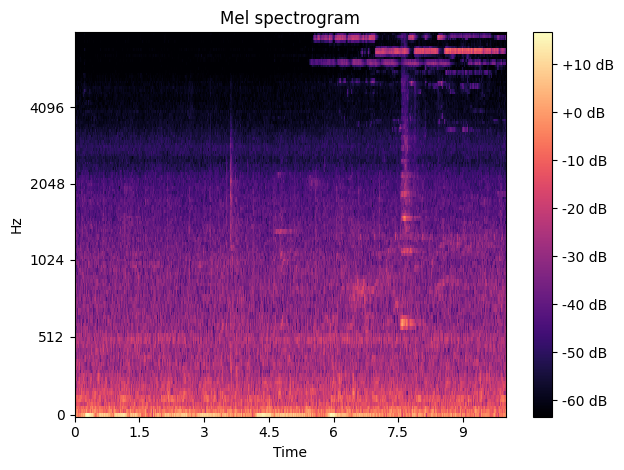

In [11]:
example_audio = random.choice(audio_files)
waveform, sample_rate = torchaudio.load(example_audio)
waveform = waveform.numpy()

print("-" * 80)
title = "PLOT AND PLAYBACK AUDIO FILES"
print("\n" + title.center(80) + "\n")
print("-" * 80)
print(f"Loaded audio file : {example_audio}")
print(f"Waveform shape    : {waveform.shape}")
print(f"Sample rate       : {sample_rate} Hz")
print("-" * 80)

u.mel_spectrogram(
    waveform,
    sample_rate,
    n_mels=128,
    hop_length=512
)

ipd.Audio(example_audio)

#### Creating Datasets

In [16]:
# create datasets
target_shape = (128, 128)
batch_size = 32

# defining audio directory
audio_dir = os.path.join(data_home, 'audio')

# filter audio files by split
train_files = [os.path.join(audio_dir, f) for f in debug_df[debug_df['split'] == 'train']['audio_filename'].unique()]
val_files = [os.path.join(audio_dir, f) for f in debug_df[debug_df['split'] == 'validate']['audio_filename'].unique()]
test_files = [os.path.join(audio_dir, f) for f in debug_df[debug_df['split'] == 'test']['audio_filename'].unique()]

# Print some info
print(f"Number of training files: {len(train_files)}")
print(f"Number of validation files: {len(val_files)}")
print(f"Number of test files: {len(test_files)}")

# Create datasets
# Create datasets with annotations
train = u.data_set(train_files, batch_size, target_shape, annotations_df=debug_df)
validation = u.data_set(val_files, batch_size, target_shape, annotations_df=debug_df)
test = u.data_set(test_files, batch_size, target_shape, annotations_df=debug_df, shuffle=False)

Number of training files: 13538
Number of validation files: 4308
Number of test files: 664


TypeError: data_set() got an unexpected keyword argument 'annotations_df'

#### SONY-UST Dataset Analysis

Sensor Distribution:
- Training: 35 sensors (IDs 1-41, 45)
- Validation: 9 sensors (IDs 0,3-7,9,10,46)
- Test: 48 sensors (mix of existing and new sensors 48-61)

Audio File Details:
- Sample rate: 48kHz
- Duration: 10 seconds (480000 samples)
- Single channel audio (shape: 1, 480000)

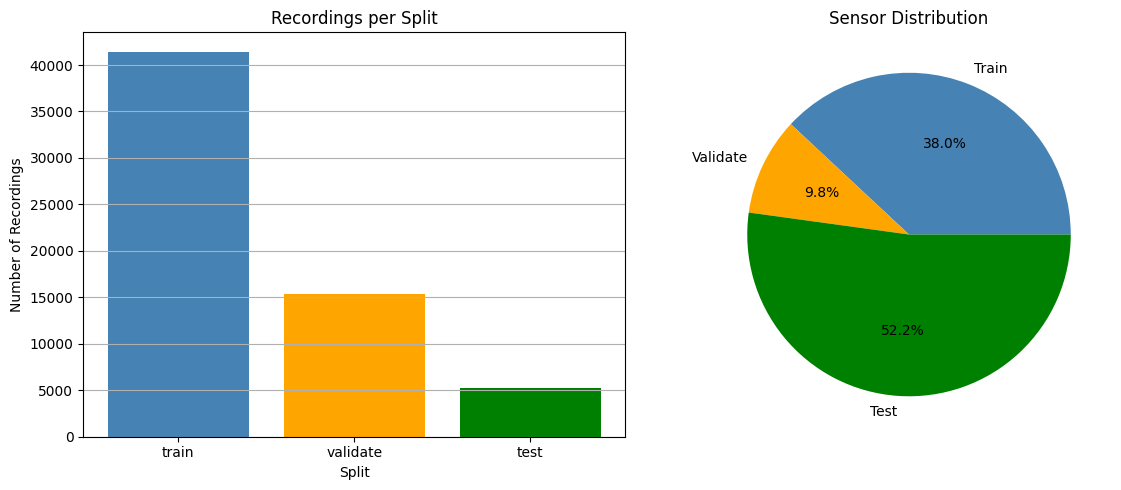

In [13]:
# adding pie chart because my mind likes it better ~ chris lanuza 2025
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
colors = ['steelblue', 'orange', 'green']
plt.bar(split_counts.index, split_counts.values, color=colors[:len(split_counts)])
plt.title('Recordings per Split')
plt.xlabel('Split')
plt.ylabel('Number of Recordings')
plt.grid(axis='y')
plt.subplot(1, 2, 2)
sensor_counts = [len(set(train_df['sensor_id'])), 
                len(set(valid_df['sensor_id'])), 
                len(set(test_df['sensor_id']))]
plt.pie(sensor_counts, labels=['Train', 'Validate', 'Test'], 
        colors=colors, autopct='%1.1f%%')
plt.title('Sensor Distribution')

plt.tight_layout()
plt.show()

#### Testing dataset creation

In [14]:
print(f"Number of training files: {len(train_files)}")
print(f"First few training files:")
for f in train_files[:3]:
    print(f"- {f}")
    full_path = os.path.join(audio_dir, f)
    print(f"  Exists: {os.path.exists(full_path)}")

# dataset creation starts here
print("Testing dataset creation...")
try:
    # Test training dataset
    for batch in train.take(1):
        x_train, y_train = batch
        print("\nTraining dataset:")
        print(f"Input shape: {x_train.shape}")
        print(f"Target shape: {y_train.shape}")
    
    # Test validation dataset
    for batch in validation.take(1):
        x_val, y_val = batch
        print("\nValidation dataset:")
        print(f"Input shape: {x_val.shape}")
        print(f"Target shape: {y_val.shape}")
    
    # Test batch sizes
    print(f"\nExpected batch size: {batch_size}")
    print(f"Actual batch sizes - Train: {x_train.shape[0]}, Validation: {x_val.shape[0]}")
    
    print("\nDataset creation successful!")
except Exception as e:
    print(f"Dataset creation failed: {str(e)}")
    print("Check your utils.py data_set function and audio processing pipeline.")

Number of training files: 13538
First few training files:
- /Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/01_000006.wav
  Exists: True
- /Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/01_000038.wav
  Exists: True
- /Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/01_000061.wav
  Exists: True
Testing dataset creation...
Error in generator for /Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/01_000006.wav: name 'debug_df' is not defined
Error in generator for /Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/01_000038.wav: name 'debug_df' is not defined
Error in generator for /Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/01_000061.wav: name 'debug_df' is not defined
Error in generator for /Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/01_000126.wav: name 'debug_df' is not defined
Error in generator for /Users/calodii/Des

2025-04-25 16:53:26.648513: W tensorflow/core/framework/op_kernel.cc:1844] INVALID_ARGUMENT: ValueError: No valid audio files processed
Traceback (most recent call last):

  File "/opt/homebrew/Caskroom/miniconda/base/envs/tf-metal/lib/python3.9/site-packages/tensorflow/python/ops/script_ops.py", line 269, in __call__
    ret = func(*args)

  File "/opt/homebrew/Caskroom/miniconda/base/envs/tf-metal/lib/python3.9/site-packages/tensorflow/python/autograph/impl/api.py", line 643, in wrapper
    return func(*args, **kwargs)

  File "/opt/homebrew/Caskroom/miniconda/base/envs/tf-metal/lib/python3.9/site-packages/tensorflow/python/data/ops/from_generator_op.py", line 198, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))

  File "/Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/utils.py", line 274, in generator
    raise ValueError("No valid audio files processed")

ValueError: No valid audio files processed


2025-04-25 16:53:26.650387: I tensorflow/core/f

#### Training Model

1. Taking the Fourier Transform to understand singal properties. Since this is a complex signal and we are dealing with real time audio it's important to construct an analytical signal using that complex signal using Hilbert's Transform
$$X(\omega) = \int{x(t)e^{-j\omega t}dt}$$

2. Mel Spectrogram Generation
Converts the frequency $(f)$ to mel scale. Power spectrum is $|X(\omega)^2|$. Mel filterbank is the weighted sum of spectral components
$$Mel(f) = 2595 * \log 10( 1 + f/700)$$

In [15]:
# multi-lable classification number of classes
# update based on number of classes
num_classes = 8

# creating and compiling
model = m.autoencoder_model(
    input_shape=(128, 128, 1),
)

# compiling model and printing summary
model = m.compile_model(model)
model.summary()

# train the model
history = m.train_model(
    model=model,
    train_data=train,
    validation_data=validation,
    epochs=50
)

# plotting results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,265 (294.00 KB)

 Trainable params: 74,881 (292.50 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50


2025-04-25 16:53:27.731024: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Error in generator for /Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/01_000006.wav: name 'debug_df' is not defined
Error in generator for /Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/01_000038.wav: name 'debug_df' is not defined
Error in generator for /Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/01_000061.wav: name 'debug_df' is not defined
Error in generator for /Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/01_000126.wav: name 'debug_df' is not defined
Error in generator for /Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/01_000143.wav: name 'debug_df' is not defined
Error in generator for /Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/01_000156.wav: name 'debug_df' is not defined
Error in generator for /Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/01_000159.wav: name 'debug_df' is not defined
Error in gene

2025-04-25 16:58:35.623653: W tensorflow/core/framework/op_kernel.cc:1844] INVALID_ARGUMENT: ValueError: No valid audio files processed
Traceback (most recent call last):

  File "/opt/homebrew/Caskroom/miniconda/base/envs/tf-metal/lib/python3.9/site-packages/tensorflow/python/ops/script_ops.py", line 269, in __call__
    ret = func(*args)

  File "/opt/homebrew/Caskroom/miniconda/base/envs/tf-metal/lib/python3.9/site-packages/tensorflow/python/autograph/impl/api.py", line 643, in wrapper
    return func(*args, **kwargs)

  File "/opt/homebrew/Caskroom/miniconda/base/envs/tf-metal/lib/python3.9/site-packages/tensorflow/python/data/ops/from_generator_op.py", line 198, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))

  File "/Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/utils.py", line 274, in generator
    raise ValueError("No valid audio files processed")

ValueError: No valid audio files processed


2025-04-25 16:58:35.625209: I tensorflow/core/f

InvalidArgumentError: Graph execution error:

Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
2 root error(s) found.
  (0) INVALID_ARGUMENT:  ValueError: No valid audio files processed
Traceback (most recent call last):

  File "/opt/homebrew/Caskroom/miniconda/base/envs/tf-metal/lib/python3.9/site-packages/tensorflow/python/ops/script_ops.py", line 269, in __call__
    ret = func(*args)

  File "/opt/homebrew/Caskroom/miniconda/base/envs/tf-metal/lib/python3.9/site-packages/tensorflow/python/autograph/impl/api.py", line 643, in wrapper
    return func(*args, **kwargs)

  File "/opt/homebrew/Caskroom/miniconda/base/envs/tf-metal/lib/python3.9/site-packages/tensorflow/python/data/ops/from_generator_op.py", line 198, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))

  File "/Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/utils.p